In [1]:
# needed if run on the cloud, e.g. jupyter lab
%pip install seaborn


[notice] A new release of pip is available: 23.2.1 -> 25.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd

# Load the CSV file
file_path = "./scxa_over_.5sec.txt"
df = pd.read_csv(file_path, sep=" ", names=['request_type', 'url', 'response_time', 'args'], header=None)

In [3]:
df["response_time"] = pd.to_numeric(df["response_time"], errors="coerce")


In [4]:
df_clean = df.dropna(subset=["response_time"])

In [7]:
summary_stats = (
    df_clean
    .groupby("request_type")["response_time"]
    .agg(
        mean="mean",
        std="std",
        min="min",
        max="max",
        median=lambda x: x.median(),
        count="count"
    )
    .reset_index()
)


In [8]:
summary_stats

,request_type,mean,std,min,max,median,count
0,download,5.194333,3.313000,4.090,14.029,4.090,9
1,experiment,80562.474082,291559.108147,4.401,1956150.000,37901.700,49
2,experiments,629.872010,4995.255230,3.639,53874.000,6.270,195
3,experiments?experimentDescription=Intestinal+S...,4.217000,NaN,4.217,4.217,4.217,1
4,experiments?experimentDescription=Signatures+o...,4.217000,NaN,4.217,4.217,4.217,1
5,experiments?experimentDescription=ovarian%2Bca...,4.217000,NaN,4.217,4.217,4.217,1
6,experiments?experimentDescription=small+cell,4.217000,NaN,4.217,4.217,4.217,1
7,experiments?kingdom=%22Animals%22,4.217000,NaN,4.217,4.217,4.217,1
8,experiments?kingdom=%22Animals%22&species=Homo...,4.217000,NaN,4.217,4.217,4.217,1
9,experiments?species=%22arabidopsis%20thaliana%22,4.217000,0.000000,4.217,4.217,4.217,6


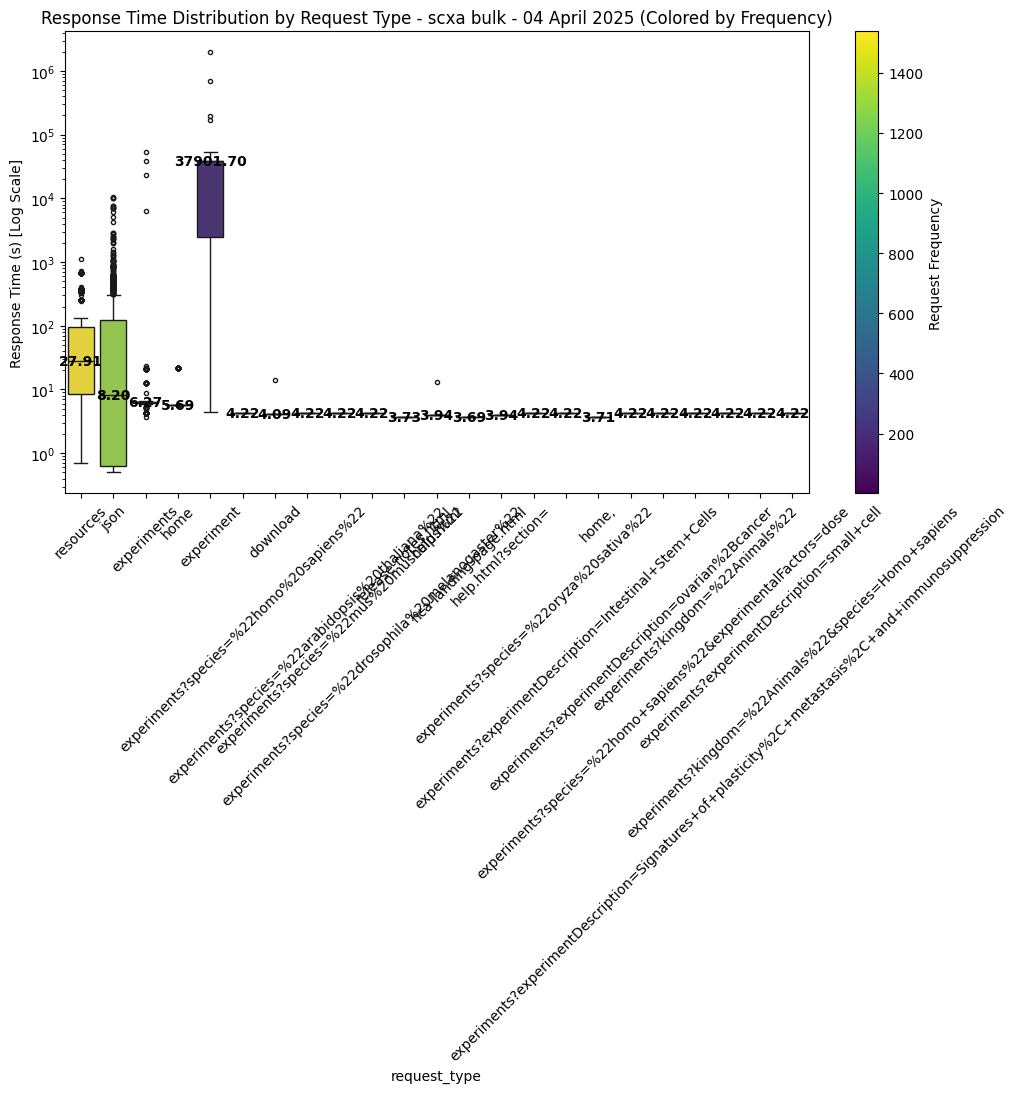

In [13]:


from matplotlib import pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors

# Ensure correct ordering of request types
request_counts = df_clean["request_type"].value_counts()
order = request_counts.index  # Ensure consistent sorting

# Normalize the frequencies for color mapping
norm = mcolors.Normalize(vmin=request_counts.min(), vmax=request_counts.max())
sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)  # Choose a heatmap colormap
colors = [sm.to_rgba(request_counts[req]) for req in order]

# Create the figure and axis
fig, ax = plt.subplots(figsize=(12, 6))

# Create the boxplot with different colors
sns.boxplot(
    data=df_clean, x="request_type", y="response_time",
    hue="request_type",
    ax=ax, order=order, palette=colors, flierprops={"marker": "o", "markersize": 3}
)

# Set y-axis to log scale for better visualization
ax.set_yscale("log")
ax.set_ylabel("Response Time (s) [Log Scale]")
plt.title("Response Time Distribution by Request Type - scxa bulk - 04 April 2025 (Colored by Frequency)")


# Calculate and add median labels correctly
medians = df_clean.groupby("request_type")["response_time"].median()
for i, req_type in enumerate(order):
    median_value = medians[req_type]
    ax.text(i, median_value, f"{median_value:.2f}", ha="center", va="center", 
            fontsize=10, color="black", fontweight="bold")


# Add color bar as a legend for frequency
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Request Frequency")

# # Rotate x-axis labels for readability
plt.xticks(rotation=45)
plt.legend().set_visible(False)

# Show the plot
plt.show()
